In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"../data/fraudTrain.csv")


df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

print(df.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


Class Imbalance Summary:
            Count  Percentage
is_fraud                     
0         1289169   99.421135
1            7506    0.578865
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


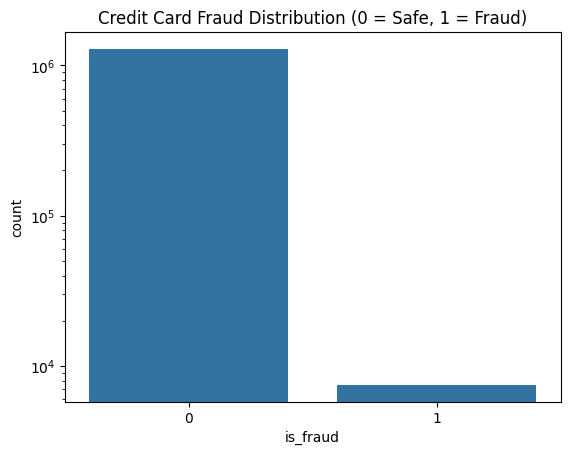

In [ ]:
counts = df['is_fraud'].value_counts()
percentages = df['is_fraud'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage': percentages})
print("Class Imbalance Summary:")
print(imbalance_summary)


print(df["is_fraud"].value_counts())

print(df["is_fraud"].value_counts(normalize=True) * 100)

sns.countplot(x="is_fraud", data=df)
plt.title("Credit Card Fraud Distribution (0 = Safe, 1 = Fraud)")
plt.yscale("log") 
plt.show()


Median fraudulent transaction amount: 396.505
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


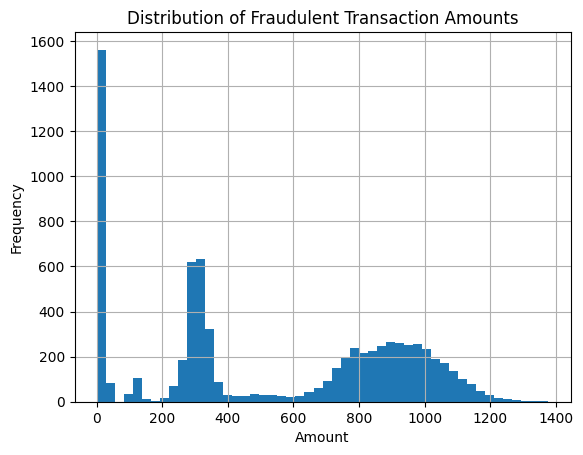

In [3]:
df[df["is_fraud"] == 1]["amt"].hist(bins=50)
fraud_amt_dist = df[df["is_fraud"] == 1]["amt"].describe()
median_fraud = df[df["is_fraud"] == 1]["amt"].median()
print(f"Median fraudulent transaction amount: {median_fraud}")
print(fraud_amt_dist)

plt.title("Distribution of Fraudulent Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

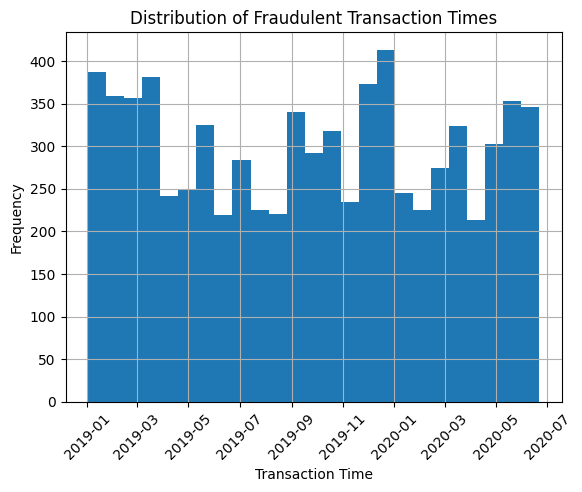

In [4]:
df[df["is_fraud"] == 1]["trans_date_trans_time"].hist(bins=25)
plt.title("Distribution of Fraudulent Transaction Times")
plt.xlabel("Transaction Time")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from geopy.distance import geodesic

m_lat, m_long, c_lat, c_long = map(
    np.radians,
    [df["merch_lat"], df["merch_long"], df["lat"], df["long"]],
)
dlat = c_lat - m_lat
dlon = c_long - m_long

a = np.sin(dlat / 2) ** 2 + np.cos(m_lat) * np.cos(c_lat) * np.sin(dlon / 2) ** 2
c = 2 * np.arcsin(np.sqrt(a))


df["distance"] = (3958.8 * c).round(2)
fraud_dist_corr = df[["distance", "is_fraud"]].corr().iloc[0, 1]
print(f"Correlation between distance and fraud: {fraud_dist_corr}")

display(df)



c:\Users\swyne\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


Correlation between distance and fraud: 0.00040295423492956443


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,48.84
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,18.77
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,67.24
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,59.45
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,48.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,74.41
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,46.67
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,61.55
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,52.59
